# Baseline Comparison Simulation — All Scenarios

Compares project-specific and standardized baselines across ranges of `p` and `c` under three distributional assumptions.

| Scenario | BAU emission b_hat | Inspection effort |
|----------|-------------------|-------------------|
| 1 | Uniform [0, e] | Uniform |
| 2 | Normal (clipped) | Normal (CDF) |
| 3 (extension) | Normal (clipped) | Exponential |


## Imports

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.optimize import minimize_scalar
from scipy.stats import norm

## Shared Parameters

In [ ]:
e = 392
r1 = 1
r2 = 2 * r1
a = e / 5

p_values = np.linspace(1, 6, 101)
c_values = np.linspace(0.01, 0.15, 101)

n_draws = 2000
seed = 123
rng = np.random.default_rng(seed)

## Monte Carlo Draws

- Scenario 1: b_hat ~ Uniform[0, e]
- Scenarios 2 & 3: b_hat ~ Normal clipped to [0, e]

In [16]:
b_hat_draws_uniform = rng.uniform(0, e, n_draws)

b_hat_draws_normal = np.clip(
    rng.normal(e / 2, math.sqrt(e**2 / 12), n_draws),
    0, e
)

## Developer Problem (shared)

In [17]:
def developer_capacity(e, b, r, p, c):
    candidates = [0, e, e - b, r / c, (r + p) / c, (r + 0.5 * p) / c]
    candidates = [min(max(k, 0), e) for k in candidates]
    def profit(k):
        return r * k + p * max(0, b - (e - k)) - 0.5 * c * k**2
    return max(candidates, key=profit)

def developer_revenue(e, b, r, p, c):
    k = developer_capacity(e, b, r, p, c)
    return r * k + p * max(0, b - (e - k)) - 0.5 * c * k**2

## Metrics (shared)

In [18]:
def supply(b, b_hat, e, k):
    return max(0, b - (e - k))

def additional_reduction(b, b_hat, e, k):
    return max(0, b_hat - (e - k))

def non_additional(b, b_hat, e, k):
    return max(0, supply(b, b_hat, e, k) - additional_reduction(b, b_hat, e, k))

## Acceptance Probability (per scenario)

- Scenario 1 Uniform: (b_hat + a - br) / (2a)
- Scenario 2 Normal CDF: 1 - Phi((br - b_hat) / (0.25 * b_hat))
- Scenario 3 Exponential: exp(-br / b_hat)

In [19]:
def accept_prob_uniform(br, b_hat):
    return max(0.0, min(1.0, (b_hat + a - br) / (2 * a)))

def accept_prob_normal(br, b_hat):
    if b_hat == 0:
        return 0.0
    return float(1 - norm.cdf((br - b_hat) / (0.25 * b_hat)))

def accept_prob_exponential(br, b_hat):
    if b_hat == 0:
        return 0.0
    return math.exp(-br / b_hat)

## Standardized & Project-Specific Baseline (parameterised)

In [20]:
def standardized_metrics(e, p, c, b_hat_draws):
    def objective(b):
        S = np.mean([supply(b, bh, e, developer_capacity(e, b, c*(e-bh), p, c)) for bh in b_hat_draws])
        N = np.mean([non_additional(b, bh, e, developer_capacity(e, b, c*(e-bh), p, c)) for bh in b_hat_draws])
        return -(r1 * S - r2 * N)
    b_star = minimize_scalar(objective, bounds=(0, e), method='bounded').x
    S_list, N_list, X_list, K_list = [], [], [], []
    for bh in b_hat_draws:
        r = c * (e - bh)
        k = developer_capacity(e, b_star, r, p, c)
        S_list.append(supply(b_star, bh, e, k))
        N_list.append(non_additional(b_star, bh, e, k))
        X_list.append(additional_reduction(b_star, bh, e, k))
        K_list.append(k)
    S, N, X, K = np.mean(S_list), np.mean(N_list), np.mean(X_list), np.mean(K_list)
    return r1 * S - r2 * N, N, K

def project_metrics(e, p, c, b_hat_draws, accept_prob_fn):
    def reported_emission(b_hat):
        r = c * (e - b_hat)
        def obj(br):
            prob = accept_prob_fn(br, b_hat)
            return -(prob * developer_revenue(e, br, r, p, c)
                     + (1 - prob) * developer_revenue(e, r/c, r, 0, c))
        return minimize_scalar(obj, bounds=(0, e), method='bounded').x
    S_list, N_list, X_list, K_list = [], [], [], []
    for bh in b_hat_draws:
        r = c * (e - bh)
        br = reported_emission(bh)
        prob = accept_prob_fn(br, bh)
        k = developer_capacity(e, br, r, p, c)
        s = prob * supply(br, bh, e, k)
        x = prob * additional_reduction(br, bh, e, k)
        S_list.append(s)
        N_list.append(max(0, s - x))
        X_list.append(x)
        K_list.append(k)
    S, N, X, K = np.mean(S_list), np.mean(N_list), np.mean(X_list), np.mean(K_list)
    return r1 * S - r2 * N, N, K

## Region Classification & Plotting (shared)

In [21]:
region_map = {
    1: ('P>S benefit', 'P<S non-additionality', 'P<S reduction'),
    2: ('P>S benefit', 'P<S non-additionality', 'P>S reduction'),
    3: ('P>S benefit', 'P>S non-additionality', 'P>S reduction'),
    4: ('P<S benefit', 'P>S non-additionality', 'P>S reduction'),
    5: ('P>S benefit', 'P>S non-additionality', 'P<S reduction'),
    6: ('P<S benefit', 'P<S non-additionality', 'P>S reduction'),
    7: ('P<S benefit', 'P<S non-additionality', 'P<S reduction'),
    8: ('P<S benefit', 'P>S non-additionality', 'P<S reduction'),
}

def classify_region(P_benefit, P_non, P_red, S_benefit, S_non, S_red):
    b = P_benefit > S_benefit
    n = P_non > S_non
    r = P_red > S_red
    if b and not n and not r: return 1
    elif b and not n and r: return 2
    elif b and n and r: return 3
    elif not b and n and r: return 4
    elif b and n and not r: return 5
    elif not b and not n and r: return 6
    elif not b and not n and not r: return 7
    elif not b and n and not r: return 8
    return 0

def compute_regions(b_hat_draws, accept_prob_fn):
    regions = np.zeros((len(p_values), len(c_values)))
    for i, p in enumerate(p_values):
        print(f'  p={p:.2f}', end='\r')
        for j, c in enumerate(c_values):
            P = project_metrics(e, p, c, b_hat_draws, accept_prob_fn)
            S = standardized_metrics(e, p, c, b_hat_draws)
            regions[i, j] = classify_region(*P, *S)
    print()
    return regions

def plot_regions(regions, title, filename):
    cmap = ListedColormap(['#FFFFFF', '#555555', '#AAAAAA', '#EEEEEE', '#888888',
                           '#FF9999', '#99CCFF', '#99FF99', '#FFCC99'])
    bounds = np.arange(-0.5, 9.5, 1)
    norm_obj = BoundaryNorm(bounds, cmap.N)
    plt.figure(figsize=(7, 5))
    plt.pcolormesh(c_values, p_values, regions, cmap=cmap, norm=norm_obj, shading='auto')
    plt.xlabel('c')
    plt.ylabel('p')
    plt.xlim(c_values.min(), c_values.max())
    plt.ylim(p_values.min(), p_values.max())
    plt.title(title)
    cbar = plt.colorbar(ticks=np.arange(0, 9))
    cbar.set_label('Region')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

def print_regions(regions):
    for region in np.unique(regions):
        region = int(region)
        if region in region_map:
            print(f'  Region {region}: {region_map[region]}')

---
## Scenario 1 — Uniform BAU + Uniform Inspection

Running Scenario 1 (Uniform + Uniform)...
  p=6.00
Regions found:
  Region 1: ('P>S benefit', 'P<S non-additionality', 'P<S reduction')
  Region 2: ('P>S benefit', 'P<S non-additionality', 'P>S reduction')
  Region 3: ('P>S benefit', 'P>S non-additionality', 'P>S reduction')
  Region 4: ('P<S benefit', 'P>S non-additionality', 'P>S reduction')


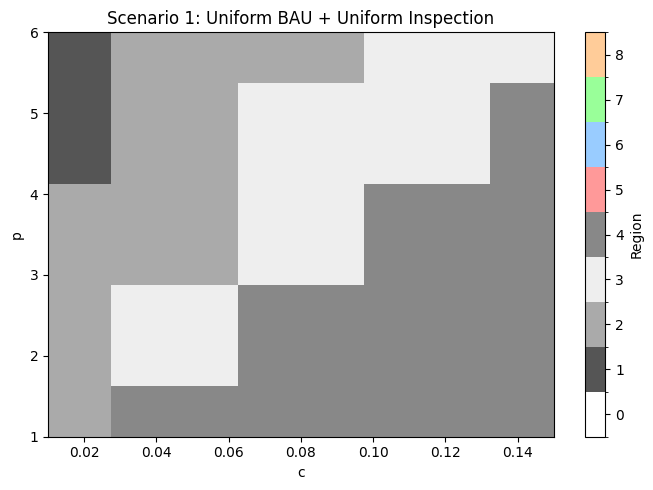

In [22]:
print('Running Scenario 1 (Uniform + Uniform)...')
regions_s1 = compute_regions(b_hat_draws_uniform, accept_prob_uniform)
print('Regions found:')
print_regions(regions_s1)
plot_regions(regions_s1,
             title='Scenario 1: Uniform BAU + Uniform Inspection',
             filename='baseline_comparison_regions_uniform_uniform.png')
np.save('regions_s1.npy', regions_s1)

---
## Scenario 2 — Normal BAU + Normal Inspection

Running Scenario 2 (Normal + Normal)...
  p=6.00
Regions found:
  Region 1: ('P>S benefit', 'P<S non-additionality', 'P<S reduction')
  Region 2: ('P>S benefit', 'P<S non-additionality', 'P>S reduction')
  Region 3: ('P>S benefit', 'P>S non-additionality', 'P>S reduction')
  Region 4: ('P<S benefit', 'P>S non-additionality', 'P>S reduction')


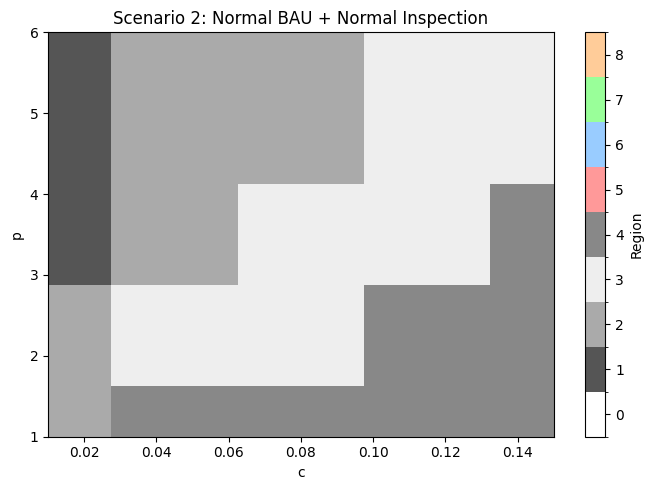

In [23]:
print('Running Scenario 2 (Normal + Normal)...')
regions_s2 = compute_regions(b_hat_draws_normal, accept_prob_normal)
print('Regions found:')
print_regions(regions_s2)
plot_regions(regions_s2,
             title='Scenario 2: Normal BAU + Normal Inspection',
             filename='baseline_comparison_regions_normal_normal.png')
np.save('regions_s2.npy', regions_s2)

---
## Scenario 3 (Extension) — Normal BAU + Exponential Inspection

Running Scenario 3 (Normal + Exponential)...
  p=6.00
Regions found:
  Region 4: ('P<S benefit', 'P>S non-additionality', 'P>S reduction')
  Region 6: ('P<S benefit', 'P<S non-additionality', 'P>S reduction')
  Region 7: ('P<S benefit', 'P<S non-additionality', 'P<S reduction')


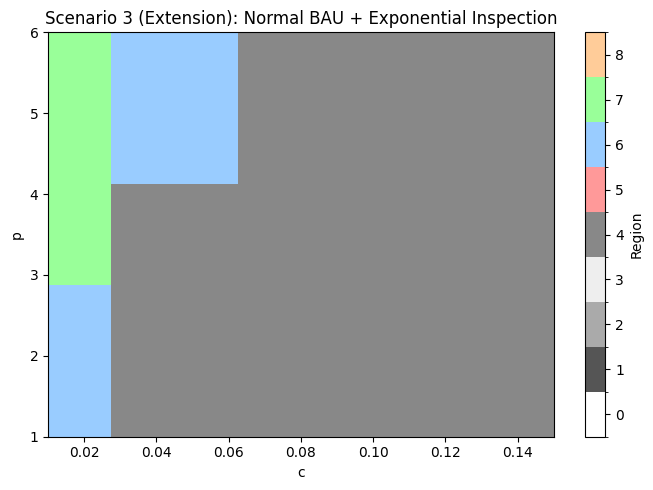

In [24]:
print('Running Scenario 3 (Normal + Exponential)...')
regions_s3 = compute_regions(b_hat_draws_normal, accept_prob_exponential)
print('Regions found:')
print_regions(regions_s3)
plot_regions(regions_s3,
             title='Scenario 3 (Extension): Normal BAU + Exponential Inspection',
             filename='baseline_comparison_regions_normal_exponential.png')
np.save('regions_s3.npy', regions_s3)